# Causal discovery: learning causal structure from data

- This notebook teaches causal discovery through interactive visualizations
  and incremental examples, building intuition about how algorithms infer
  causal structure from observational data
- The pedagogical arc:
  - Correlation vs causation, Markov equivalence, and why the direction of
    an edge matters for interventions
  - The PC algorithm (conditional independence tests), score-based search
    with GES, and LiNGAM for non-Gaussian data
  - Comparing the three algorithms on the same data
  - Validating discovered DAGs with refutation tests, and integrating domain
    knowledge
  - An end-to-end workflow from data to a validated DAG

In [ ]:
import helpers.hmodule as hmodule

# `networkx` is an extra for this notebook, not in the shared
# requirements.txt, so it is self-installed here.
hmodule.install_module_if_not_present(
    ["networkx"],
    use_activate=True,
    use_sudo=False,
    venv_path="/opt/venv",
)

import networkx

print("networkx version: ", networkx.__version__)

In [ ]:
%load_ext autoreload
%autoreload 2

import logging


In [ ]:
import helpers.hintrospection as hintros
import helpers.hnotebook as hnotebook

import L10_2_causal_discovery_utils as utils

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
_LOG = logging.getLogger(__name__)
utils.init_loggers(_LOG)

# Convert `display` into `print()` when running outside IPython.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

# Part 1: The Core Problem: Correlation vs. Causation

## Cell 1.1: Two DAGs, one correlation

**Goal**
- Recognize that identical observational patterns can hide opposite
  causal implications

**Description**
- Inputs
  - `seed`: random seed for the sampled data
  - `Correlation (r)`: strength of correlation between $X$ and $Y$
  - `Mode`: toggle between observational and interventional framing

- Panels
  - `Chain: X -> Y`: scatter plot, with a note that intervening on
    $X$ changes $Y$
  - `Reverse: Z -> Y -> X`: scatter plot with the identical
    correlation, but intervening on $X$ has no effect
  - `Comments`: current seed and correlation, plus the key
    takeaway

In [10]:
utils.cell1_correlation_vs_causation()

**Guided usage**
- Raise `Correlation (r)` toward its max
  - Observe both panels' correlation grows identically, even though
    one structure is causal and the other is not
- Compare the 2 panels at any setting
  - Observe prediction and causation require fundamentally different
    reasoning: no amount of observational data alone distinguishes
    these structures, we need additional assumptions or interventions

**Implementation** `utils.cell1_correlation_vs_causation()`
- Generates data from a chain `X -> Y` and a reverse `Z -> Y -> X`
  structure that produce the same `X`/`Y` correlation

In [ ]:
hintros.print_obj_info(utils.cell1_correlation_vs_causation)

# Part 2: Markov Equivalence: Three Indistinguishable Structures

## Cell 2.1: Same independencies, different DAGs

**Goal**
- Show that different DAGs encode identical conditional independencies
- Introduce the CPDAG as the best we can do with observational data
  alone
- Understand why causal discovery outputs equivalence classes, not
  unique DAGs

**Description**
- Inputs
  - `seed`: random seed for the sampled data
  - `Sample Size (N)`: number of observations

- Panels
  - `Chain`/`Reverse`/`Common Cause`: the 3 Markov-equivalent DAGs
  - **CI text**: states the shared independence $X \perp Z \mid Y$
  - `Marginal Correlation`/`Conditional Correlation`: bar charts of
    corr($X$, $Z$) and corr($X$, $Z \mid Y$)
  - `Comments`: current seed, $N$, and the 2 correlation values

In [11]:
utils.cell2_markov_equivalence()

**Guided usage**
- Raise `Sample Size (N)` from its min to its max
  - Observe the marginal and conditional correlations stay about the
    same: larger samples provide stronger statistical power for CI
    tests, but even infinite samples cannot distinguish Markov
    equivalent structures
- Compare the 3 DAGs
  - Observe all 3 satisfy the same independencies and have identical
    covariance matrices, so observational data alone recovers only
    the CPDAG, never a unique DAG

**Implementation** `utils.cell2_markov_equivalence()`
- Generates data from a chain `X -> Y -> Z`, then computes the
  marginal and conditional (given $Y$) correlation between $X$ and $Z$

In [ ]:
hintros.print_obj_info(utils.cell2_markov_equivalence)

# Part 3: Why Direction Matters: Causal Effects via Intervention

## Cell 3.1: Same correlation, different interventions

**Goal**
- Show concretely why edge direction determines causal effect
- Build intuition for why structure recovery is crucial for policy
- Demonstrate that the same correlation leads to wildly different
  intervention outcomes

**Description**
- Inputs
  - `seed`: random seed for the sampled data
  - `Intervention Strength`: magnitude of the change applied to
    $X$
  - `Sample Size (N)`: observations used for effect estimation

- Panels
  - `Chain: X -> Y -> Z`: large effect on $Z$ (green bar)
  - `Reverse: Z -> Y -> X`: no effect on $Z$ (red bar)
  - `Common Cause`: no direct effect on $Z$ (orange bar)
  - `Comments`: current parameters and the key takeaway

In [12]:
utils.cell3_causal_effects()

**Guided usage**
- Raise `Intervention Strength`
  - Observe only the chain's bar grows: the reverse and common-cause
    bars stay at 0 regardless of intervention strength
- Compare the 3 bars at any setting
  - Observe the same observational correlation produces wildly
    different causal effects: choosing the wrong DAG leads to
    ineffective or harmful interventions

**Implementation** `utils.cell3_causal_effects()`
- Simulates intervening on $X$ (set to a high value) and measures the
  effect on $Z$ under 3 structures: chain, reverse, common cause

In [ ]:
hintros.print_obj_info(utils.cell3_causal_effects)

# Part 4: The PC Algorithm: Learning From Conditional Independence Tests

## Cell 4.1: Testing independence, then orienting edges

**Goal**
- Understand constraint-based discovery
- See step-by-step how PC uses conditional independence (CI) tests
- Build intuition for why CI tests are powerful but fallible

**Description**
- Inputs
  - `Alpha (CI threshold)`: significance level for CI tests
  - `Test Type`: CI test method (partial correlation, Gaussian
    G-squared, conditional MI)
  - `Speed`: animation speed for the step-by-step progression

- Panels
  - `PC Algorithm Progression`: the evolving graph structure as
    edges are removed
  - `Current Test`: the current step, its p-value, and the
    separating set
  - `Comments`: current parameters and the algorithm's guarantees

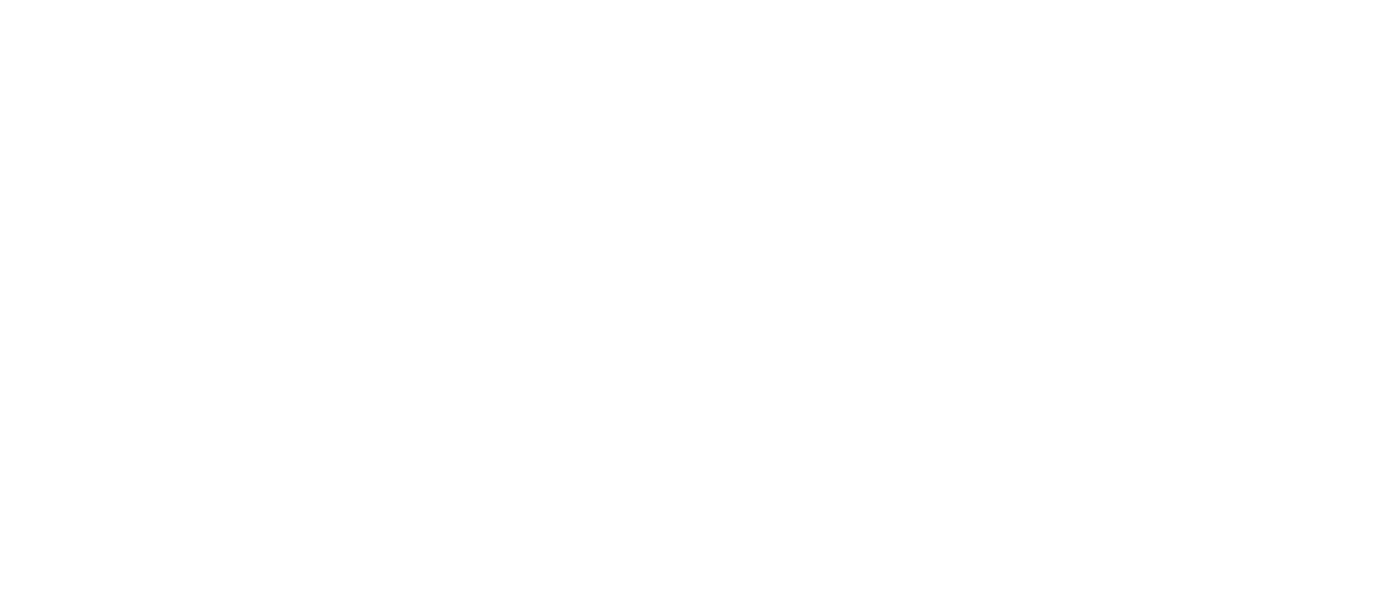

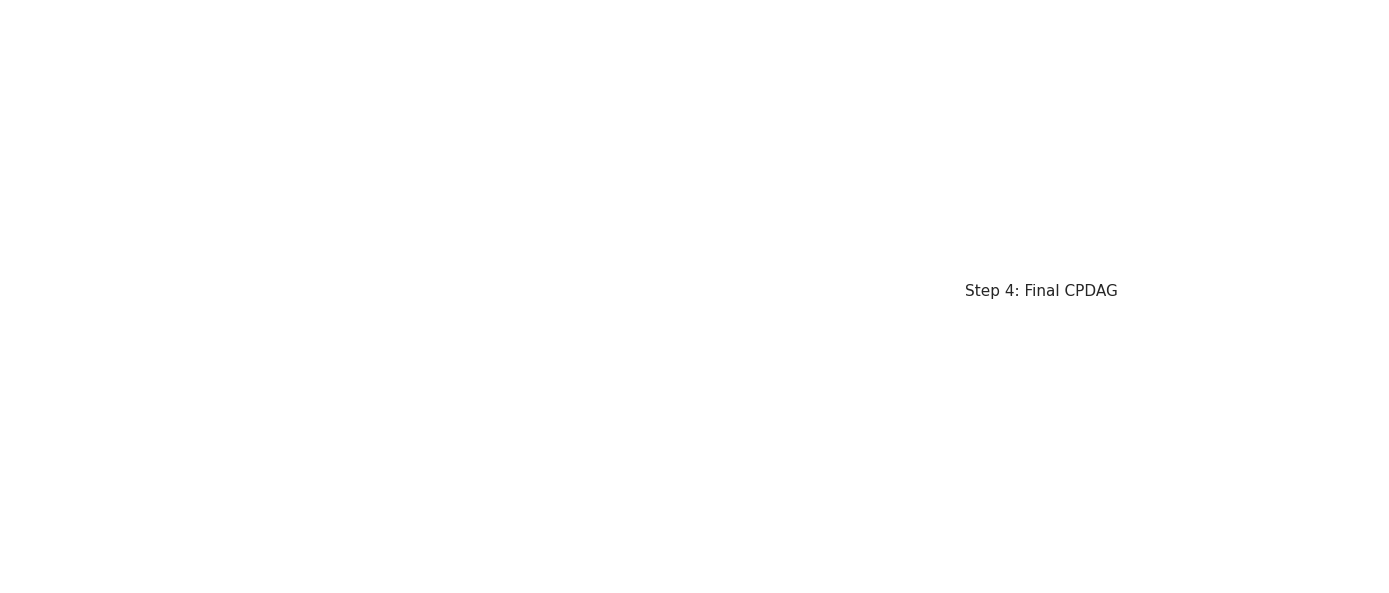

PC Algorithm: Sound in large sample limit, but CI tests are underpowered in finite samples.


In [14]:
utils.cell4_pc_algorithm()

**Guided usage**
- Lower `Alpha (CI threshold)`
  - Observe stricter tests keep more edges
- Raise `Alpha (CI threshold)`
  - Observe more liberal tests remove more edges
- Switch `Test Type`
  - Observe stronger distributional assumptions enable more powerful
    tests; PC is sound in the large-sample limit, but CI tests are
    underpowered in finite samples

**Implementation** `utils.cell4_pc_algorithm()`
- Steps through a simplified PC run on a 3-node graph: test, remove
  edges that pass, then orient v-structures

In [ ]:
hintros.print_obj_info(utils.cell4_pc_algorithm)

# Part 5: Score-Based Search: GES (Greedy Equivalence Search)

## Cell 5.1: Optimizing a score instead of testing independence

**Goal**
- Introduce score-based discovery, where algorithms optimize fit to
  data
- Show how BIC balances likelihood fit with model complexity
- Understand the forward-backward search strategy

**Description**
- Inputs
  - `Sample Size (N)`: number of observations (the BIC penalty is
    proportional to $\log(N)$)
  - `Regularization`: strength of the sparsity penalty

- Panels
  - `Current DAG Structure`: the DAG found at the current settings
  - `Score Trajectory (GES Search)`: BIC score vs. iteration, with
    the forward/backward transition marked
  - `Comments`: current parameters and the search strategy

In [ ]:
utils.cell5_ges_algorithm()

**Guided usage**
- Raise `Sample Size (N)`
  - Observe larger $N$ allows more edges, since the BIC complexity
    penalty ($\propto \log N$) grows slower than the likelihood gain
- Raise `Regularization`
  - Observe fewer edges survive; greedy search can get stuck in local
    optima, so multiple random starts improve robustness

**Implementation** `utils.cell5_ges_algorithm()`
- Simulates a BIC trajectory across search iterations, with a
  forward/backward phase transition marker

In [ ]:
hintros.print_obj_info(utils.cell5_ges_algorithm)

# Part 6: Non-Gaussian Methods: LiNGAM for Full Identifiability

## Cell 6.1: Breaking symmetry with non-Gaussian noise

**Goal**
- Show how non-Gaussianity breaks directional symmetry
- Enable full DAG recovery instead of just equivalence classes
- Build intuition for when functional assumptions are powerful

**Description**
- Inputs
  - `seed`: random seed for the sampled data
  - `Skewness`: non-Gaussianity of the noise distribution (0 =
    Gaussian)
  - `Signal-to-Noise Ratio`: ratio of signal to noise strength

- Panels
  - `X -> Y`/`Y -> Z`/`X -> Z (indirect)`: scatter plots of each
    pair
  - `Comments`: current parameters, the Jarque-Bera test result,
    and the key takeaway

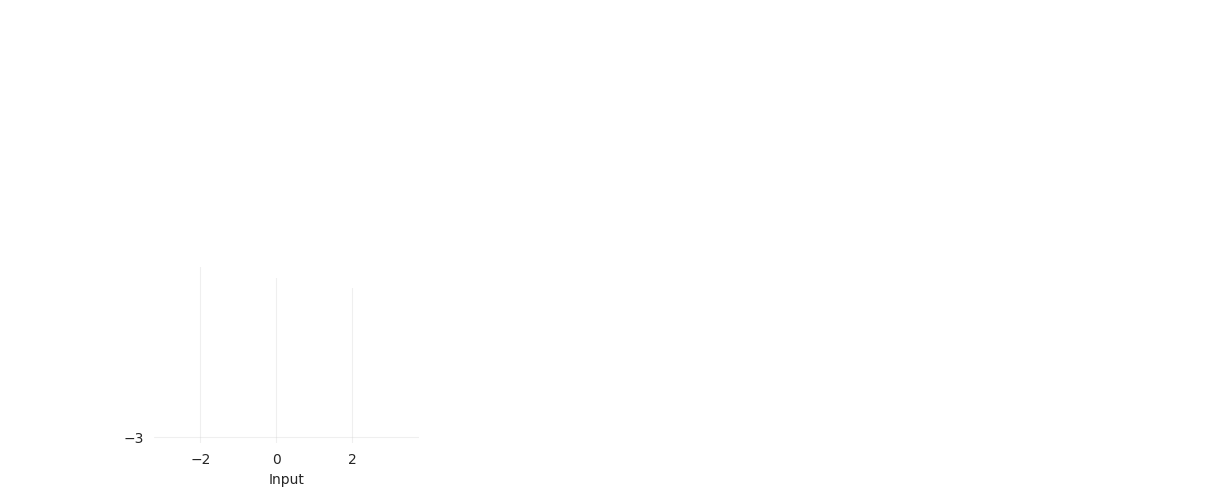


Jarque-Bera Test: statistic=0.5850, p-value=0.7464
Result: Data appear GAUSSIAN (cannot reject normality)


In [15]:
utils.cell6_lingam_nongaussian()

**Guided usage**
- Set `Skewness` to 0
  - Observe the Jarque-Bera test in Comments cannot reject normality,
    and the chains are symmetric, so their direction is
    indistinguishable
- Raise `Skewness`
  - Observe the test rejects normality, and the scatter plots become
    visibly asymmetric: LiNGAM exploits this asymmetry to orient
    edges and recover the full DAG

**Implementation** `utils.cell6_lingam_nongaussian()`
- Generates a chain with skewed (or Gaussian) noise, and runs a
  Jarque-Bera test for non-Gaussianity

In [ ]:
hintros.print_obj_info(utils.cell6_lingam_nongaussian)

# Part 7: Comparing Algorithms: Which One to Use?

## Cell 7.1: PC, GES, and LiNGAM on the same data

**Goal**
- Show outputs from PC, GES, and LiNGAM on the same data
- Build intuition for algorithm selection based on assumptions
- Understand consensus edges as most trustworthy

**Description**
- Inputs
  - `Dataset Type`: nature of the data (linear Gaussian, linear
    non-Gaussian, nonlinear)
  - `Sample Size (N)`: number of observations

- Panels
  - `PC (Constraint-Based)`: CPDAG output, with an edge/ambiguity
    count
  - `GES (Score-Based)`: full DAG output
  - `LiNGAM (Functional)`: full DAG output
  - `Comments`: current parameters and each algorithm's tradeoffs

In [ ]:
utils.cell7_algorithm_comparison()

**Guided usage**
- Switch `Dataset Type` across all 3 options
  - Observe the edge/ambiguity counts stay fixed in this simplified
    demo, but in practice: PC is good for exploratory analysis, GES
    assumes no hidden confounders, and LiNGAM requires non-Gaussianity
- Raise `Sample Size (N)`
  - Observe the Comments panel updates with the new sample size;
    consensus edges found by multiple algorithms are the most
    trustworthy

**Implementation** `utils.cell7_algorithm_comparison()`

In [ ]:
hintros.print_obj_info(utils.cell7_algorithm_comparison)

# Part 8: Validating Discovered DAGs with Refutation Tests

## Cell 8.1: Checking whether a DAG's implications hold

**Goal**
- Show how to validate that a discovered DAG's implications hold in
  the data
- Understand refutation as a check on model assumptions
- Build sensitivity to hidden confounding

**Description**
- Inputs
  - `Alpha (CI threshold)`: significance level for validation
  - `Confounder Strength`: magnitude of hidden confounding

- Panels
  - `CI Test Validation`: bar chart of p-values for implied
    independencies (green: holds, red: violated)
  - `Placebo Test`: discovery output on shuffled data (should find
    ~0 edges)
  - `Sensitivity Analysis`: robustness vs. hidden confounder
    strength
  - `Comments`: current parameters and the validation score

In [ ]:
utils.cell8_validation()

**Guided usage**
- Lower `Alpha (CI threshold)`
  - Observe fewer bars in `CI Test Validation` turn red, since the
    threshold for "violated" becomes stricter
- Raise `Confounder Strength`
  - Observe the `Sensitivity Analysis` robustness curve drops faster:
    a discovered DAG is a hypothesis, and validation checks its
    consistency with the data, it does not prove it

**Implementation** `utils.cell8_validation()`

In [ ]:
hintros.print_obj_info(utils.cell8_validation)

# Part 9: Domain Knowledge Integration: Constraints and Prior DAGs

## Cell 9.1: Combining expert knowledge with discovery

**Goal**
- Show how expert knowledge (forbidden/required edges, temporal
  order) drastically improves discovery accuracy without losing
  data-driven insights
- Understand constraint-based discovery as combining human and
  machine intelligence

**Description**
- Inputs
  - `Prior Strength`: how much to trust expert knowledge

- Panels
  - `No Constraints`: fully automatic discovery result
  - `With Constraints`: discovery with the expert constraints
    applied, fewer ambiguities
  - `Comments`: the expert constraints, and the impact summary
    (search-space reduction, edges affected)

In [16]:
utils.cell9_domain_knowledge()

**Guided usage**
- Raise `Prior Strength`
  - Observe the impact summary in Comments reports a bigger search-
    space reduction
- Compare `No Constraints` vs `With Constraints`
  - Observe temporal ordering is the strongest constraint: expert and
    automated discovery are complementary, and combining them gives
    the best results, but wrong priors inject errors

**Implementation** `utils.cell9_domain_knowledge()`

In [ ]:
hintros.print_obj_info(utils.cell9_domain_knowledge)

# Part 10: End-to-End Workflow: From Data to Validated DAG

## Cell 10.1: The full discovery pipeline

**Goal**
- Integrate all techniques into a complete discovery pipeline
- Show the practical workflow from raw data to validated causal
  structure
- Understand causal discovery as an iterative, multi-stage process

**Description**
- Inputs
  - `Dataset`: type of data (synthetic: linear Gaussian,
    non-Gaussian; real: economic)
  - `PC`/`GES`/`LiNGAM`: checkboxes selecting which algorithms to
    run
  - `Progress Stage`: current stage in the workflow (0 to 5)

- Panels
  - `Stage 1-6`: one panel per pipeline stage, highlighted once
    reached
  - `Overall Progress`: a progress bar over all 6 stages

In [ ]:
utils.cell10_end_to_end_workflow()

**Guided usage**
- Move `Progress Stage` from 0 to 5
  - Observe each stage panel highlights in turn, and the progress bar
    fills up: discovery is a pipeline, not a single algorithm call
- Toggle the `PC`/`GES`/`LiNGAM` checkboxes
  - Observe the `Stage 2: Algorithms` panel updates with the selected
    set; multiple algorithms provide robustness via consensus

**Implementation** `utils.cell10_end_to_end_workflow()`
- 6 stages: data preparation, algorithm selection, consensus,
  refinement, validation, and the final DAG

In [ ]:
hintros.print_obj_info(utils.cell10_end_to_end_workflow)

# Summary

Causal discovery is a powerful tool for inferring causal structure from
observational data, but it requires careful attention to:

- **Assumptions**: Different algorithms make different assumptions
  about the data
- **Identifiability**: Some structures are inherently unidentifiable
  from observational data
- **Validation**: Discovered DAGs must be validated and
  sensitivity-tested
- **Domain Knowledge**: Expert knowledge dramatically improves results
- **Interpretation**: Discovered structures are hypotheses for
  investigation, not definitive proofs

The workflow balances automated discovery with expert judgment,
validated with refutation tests, and interpreted as a hypothesis for
investigation.